In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

os.chdir(r'c:\Users\sachi\Desktop\ETA_Optimization')

df = pd.read_csv('delivery_data.csv')
node_metrics = pd.read_csv('outputs/node_metrics.csv')
edge_weights = pd.read_csv('outputs/edge_weight_table.csv')

print("Main data:", df.shape)
print("Node metrics:", node_metrics.shape)
print("\nNode metrics columns:", node_metrics.columns.tolist())
print("\nNode metrics sample:")
print(node_metrics.head())

Main data: (144867, 24)
Node metrics: (1657, 10)

Node metrics columns: ['center', 'name', 'betweenness', 'in_degree', 'out_degree', 'in_degree_weighted', 'out_degree_weighted', 'clustering', 'avg_incoming_delay_factor', 'bottleneck_score']

Node metrics sample:
         center                                name  betweenness  in_degree  \
0  IND000000ACB       Gurgaon_Bilaspur_HB (Haryana)     0.233538         45   
1  IND712311AAA    Kolkata_Dankuni_HB (West Bengal)     0.073511         24   
2  IND209304AAA  Kanpur_Central_H_6 (Uttar Pradesh)     0.036469         16   
3  IND562132AAA    Bangalore_Nelmngla_H (Karnataka)     0.122355         36   
4  IND600056AAB     MAA_Poonamallee_HB (Tamil Nadu)     0.043386         18   

   out_degree  in_degree_weighted  out_degree_weighted  clustering  \
0          49           90.927216            97.782163    0.036612   
1          21          116.915023            56.250436    0.039773   
2          13          122.256870            28.8048

In [2]:
# Merge node metrics for source hub
df = df.merge(
    node_metrics[['center', 'betweenness', 'in_degree', 'out_degree', 
                  'avg_incoming_delay_factor', 'bottleneck_score']],
    left_on='source_center',
    right_on='center',
    how='left'
).rename(columns={
    'betweenness': 'src_betweenness',
    'in_degree': 'src_in_degree',
    'out_degree': 'src_out_degree',
    'avg_incoming_delay_factor': 'src_avg_delay',
    'bottleneck_score': 'src_bottleneck_score'
}).drop(columns='center')

# Merge node metrics for destination hub
df = df.merge(
    node_metrics[['center', 'betweenness', 'in_degree', 'out_degree',
                  'avg_incoming_delay_factor', 'bottleneck_score']],
    left_on='destination_center',
    right_on='center',
    how='left'
).rename(columns={
    'betweenness': 'dst_betweenness',
    'in_degree': 'dst_in_degree',
    'out_degree': 'dst_out_degree',
    'avg_incoming_delay_factor': 'dst_avg_delay',
    'bottleneck_score': 'dst_bottleneck_score'
}).drop(columns='center')

print("New shape:", df.shape)
print("\nNew columns added:", df.columns.tolist()[-10:])

# Merge quality check
graph_metric_cols = [
    'src_betweenness', 'src_in_degree', 'src_out_degree', 'src_avg_delay', 'src_bottleneck_score',
    'dst_betweenness', 'dst_in_degree', 'dst_out_degree', 'dst_avg_delay', 'dst_bottleneck_score'
]
null_counts = df[graph_metric_cols].isnull().sum()
print("\nNull counts after merge (rows that did not match node_metrics):")
print(null_counts)
print(f"\nRows with any missing graph metric: {df[graph_metric_cols].isnull().any(axis=1).sum()} / {len(df)}")

New shape: (144867, 34)

New columns added: ['src_betweenness', 'src_in_degree', 'src_out_degree', 'src_avg_delay', 'src_bottleneck_score', 'dst_betweenness', 'dst_in_degree', 'dst_out_degree', 'dst_avg_delay', 'dst_bottleneck_score']

Null counts after merge (rows that did not match node_metrics):
src_betweenness         0
src_in_degree           0
src_out_degree          0
src_avg_delay           0
src_bottleneck_score    0
dst_betweenness         0
dst_in_degree           0
dst_out_degree          0
dst_avg_delay           0
dst_bottleneck_score    0
dtype: int64

Rows with any missing graph metric: 0 / 144867


In [3]:
# Extract time features
df['trip_creation_time'] = pd.to_datetime(df['trip_creation_time'])
df['hour_of_day'] = df['trip_creation_time'].dt.hour
df['day_of_week'] = df['trip_creation_time'].dt.dayofweek

# Encode route type (FTL=1, Carting=0)
df['is_ftl'] = (df['route_type'] == 'FTL').astype(int)

print("Actual time stats:")
print(df['actual_time'].describe())
print("\nRoute type distribution:")
print(df['route_type'].value_counts())

Actual time stats:
count    144867.000000
mean        416.927527
std         598.103621
min           9.000000
25%          51.000000
50%         132.000000
75%         513.000000
max        4532.000000
Name: actual_time, dtype: float64

Route type distribution:


route_type
FTL        99660
Carting    45207
Name: count, dtype: int64


In [4]:
print(df['data'].unique())
print(df['data'].value_counts())

<StringArray>
['training', 'test']
Length: 2, dtype: str
data
training    104858
test         40009
Name: count, dtype: int64


In [5]:
train = df[df['data'] == 'training'].copy()
test = df[df['data'] == 'test'].copy()

print("Train size:", train.shape)
print("Test size:", test.shape)

# Define features
baseline_features = [
    'osrm_time', 
    'osrm_distance', 
    'is_ftl',
    'hour_of_day', 
    'day_of_week'
]

graph_features = baseline_features + [
    'src_betweenness', 'src_in_degree', 'src_out_degree',
    'src_avg_delay', 'src_bottleneck_score',
    'dst_betweenness', 'dst_in_degree', 'dst_out_degree',
    'dst_avg_delay', 'dst_bottleneck_score'
]

target = 'actual_time'

print("\nTrain/Test split looks good!")

Train size: (104858, 37)
Test size: (40009, 37)

Train/Test split looks good!


In [6]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# Prepare data
X_train_base = train[baseline_features].fillna(0)
X_test_base = test[baseline_features].fillna(0)
y_train = train[target]
y_test = test[target]

# Train baseline model
print("Training baseline model...")
baseline_model = XGBRegressor(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
baseline_model.fit(X_train_base, y_train)

# Evaluate
y_pred_base = baseline_model.predict(X_test_base)
base_mae = mean_absolute_error(y_test, y_pred_base)

valid_mask = y_test > 0
base_within_15 = np.mean(
    np.abs(y_pred_base[valid_mask] - y_test[valid_mask]) / y_test[valid_mask] <= 0.15
) * 100

print(f"Baseline MAE: {base_mae:.2f} minutes")
print(f"Baseline within 15%: {base_within_15:.1f}%")

Training baseline model...


Baseline MAE: 60.00 minutes
Baseline within 15%: 42.7%


In [7]:
# Train graph-enhanced model
graph_metric_cols = [c for c in graph_features if c not in baseline_features]

X_train_graph = train[graph_features].copy()
X_test_graph = test[graph_features].copy()

# Baseline features: fill with 0 (these should not have nulls)
X_train_graph[baseline_features] = X_train_graph[baseline_features].fillna(0)
X_test_graph[baseline_features] = X_test_graph[baseline_features].fillna(0)

# Graph metrics: fill with training median to avoid distorting unmatched hubs
graph_medians = X_train_graph[graph_metric_cols].median()
X_train_graph[graph_metric_cols] = X_train_graph[graph_metric_cols].fillna(graph_medians)
X_test_graph[graph_metric_cols] = X_test_graph[graph_metric_cols].fillna(graph_medians)

print("Training graph-enhanced model...")
graph_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
graph_model.fit(X_train_graph, y_train)

# Evaluate
y_pred_graph = graph_model.predict(X_test_graph)
graph_mae = mean_absolute_error(y_test, y_pred_graph)

valid_mask = y_test > 0
graph_within_15 = np.mean(
    np.abs(y_pred_graph[valid_mask] - y_test[valid_mask]) / y_test[valid_mask] <= 0.15
) * 100

print(f"Graph model MAE: {graph_mae:.2f} minutes")
print(f"Graph model within 15%: {graph_within_15:.1f}%")

# Show the improvement
print(f"\nMAE improvement: {((base_mae - graph_mae)/base_mae)*100:.1f}%")
print(f"Within-15% improvement: +{graph_within_15 - base_within_15:.1f} percentage points")

Training graph-enhanced model...


Graph model MAE: 43.65 minutes
Graph model within 15%: 54.2%

MAE improvement: 27.2%
Within-15% improvement: +11.5 percentage points


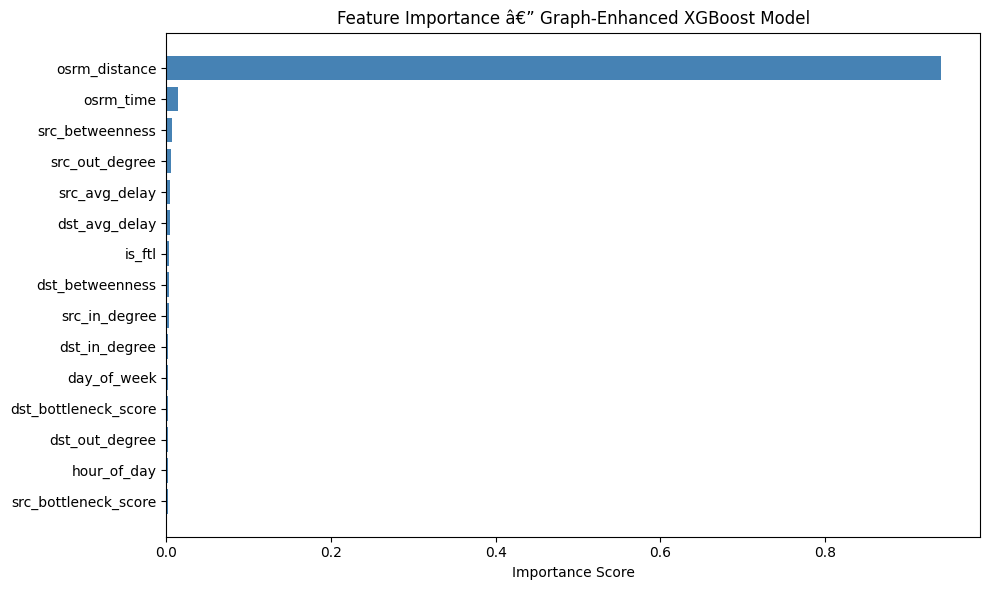

Saved: feature_importance.png


In [8]:
import matplotlib.pyplot as plt

# Get feature importances
feature_names = graph_features
importances = graph_model.feature_importances_

# Sort them
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance â€” Graph-Enhanced XGBoost Model')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("Saved: feature_importance.png")